# Step 1 — EMG preprocessing & peri-stimulus bout extraction

First stage of the flight-arena EMG analysis pipeline. It batch-converts raw `.mat` recordings into per-bout CSV files. For every `.mat` file it loads the 9-channel acquisition data, extracts the relevant traces (wingbeat frequency, raw EMG, optogenetic stimulus, wing-beat amplitude, arena x-position, and the auxiliary `hutchens` channel = `Data[7]`), detects DLMn spikes with an adaptive threshold, reads the planned optogenetic stimulus order, and slices the recording into peri-stimulus *bouts* (5 s before onset, the stimulus, and 15 s after) — saving one CSV per bout.

**Inputs:** a folder of `.mat` recordings + the shared helper module `spiracle_helper_functions.py`.  
**Outputs:** an `output_csv/` folder of per-bout CSVs.  
**Downstream:** Step 2 (quality-check plots) and Step 3 (spike amplitude filtering).

All heavy lifting lives in the helper module; this notebook is mostly the driver loop. The cells below the *Legacy* heading are exploratory / manual-inspection tools, not part of the batch pipeline.

---

# 第一步 —— EMG 预处理与刺激周围片段提取

飞行竞技场 EMG 分析流程的第一阶段。它将原始 `.mat` 记录批量转换为按片段（bout）保存的 CSV 文件。对每个 `.mat` 文件，载入 9 通道采集数据，提取所需信号（翅拍频率、原始 EMG、光遗传刺激、翅拍幅度、竞技场 x 位置，以及辅助通道 `hutchens` = `Data[7]`），用自适应阈值检测 DLMn 锋电位，读取预设的光遗传刺激顺序，并将记录切分为刺激周围的*片段*（刺激起始前 5 秒、刺激本身、以及刺激后 15 秒）——每个片段保存为一个 CSV。

**输入：** 一个装有 `.mat` 记录的文件夹 + 共享辅助模块 `spiracle_helper_functions.py`。  
**输出：** 一个装有按片段保存 CSV 的 `output_csv/` 文件夹。  
**下游：** 第二步（质量检查绘图）与第三步（锋电位幅度筛选）。

繁重的计算都在辅助模块中完成；本 notebook 主要是驱动循环。*Legacy*（历史遗留）标题以下的单元为探索性／人工检查工具，不属于批处理流程。

**Imports.** Loads the standard scientific Python stack used throughout the notebook (NumPy, Matplotlib, pandas, `os`, and `tqdm` for progress bars).

**导入库。** 载入整个 notebook 通用的标准科学计算库（NumPy、Matplotlib、pandas、`os`，以及用于显示进度条的 `tqdm`）。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from tqdm import tqdm

## Batch-process all `.mat` files into per-bout CSVs

Sets the input/output directories, loads the helper functions via `%run`, finds every `.mat` file in `input_directory`, and runs `process_single_file` on each. For every recording that helper detects spikes, parses the optogenetic stimulus order, extracts each peri-stimulus bout, and writes it to `output_directory` as `<recording>_bout<N>_stim<ms>ms.csv`.

**将所有 `.mat` 文件批量处理为按片段保存的 CSV**

设置输入/输出目录，通过 `%run` 载入辅助函数，找出 `input_directory` 中的每个 `.mat` 文件，并对每个文件运行 `process_single_file`。对每段记录，该辅助函数会检测锋电位、解析光遗传刺激顺序、提取每个刺激周围片段，并以 `<记录名>_bout<编号>_stim<毫秒>ms.csv` 的形式写入 `output_directory`。

In [2]:
# Import the helper functions
%run '/Users/camellyc/Library/Mobile Documents/com~apple~CloudDocs/学习/Lab/Tuthill Lab/Codes/Flight_Arena_Analysis/spiracle_helper_functions.py'

# Set the directories
# examples:
# input_directory = '/Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/EMG_Analysis/6_DNg27_ChR/251120_DNg27_gen1_ChR_EMG_Fly4'
# output_directory = '/Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/EMG_Analysis/6_DNg27_ChR/251120_DNg27_gen1_ChR_EMG_Fly4/output_csv'
input_directory = '/Users/camellyc/Desktop/untitled folder/'
output_directory = '/Users/camellyc/Desktop/untitled folder/output_csv'

# Create output directory if it doesn't exist
os.makedirs(output_directory, exist_ok=True)

# Check existing files in output directory
existing_files = os.listdir(output_directory) if os.path.exists(output_directory) else []
if existing_files:
    print(f"Found {len(existing_files)} existing files in output directory")

# Get list of .mat files
mat_files = [f for f in os.listdir(input_directory) if f.endswith('.mat')]
print(f"Found {len(mat_files)} .mat files to process")

# Process each file
for file_name in tqdm(mat_files, desc="Processing files"):
    try:
        # Construct full file path
        file_path = os.path.join(input_directory, file_name)
        
        # Process the file
        saved_files = process_single_file(file_path, output_directory)
        print(f"\nProcessed {file_name}:")
        print(f"Saved {len(saved_files)} bout files")
        
    except Exception as e:
        print(f"Error processing {file_name}: {e}")
        traceback.print_exc()

print("\nProcessing complete!")

Found 8 .mat files to process


Processing files:   0%|          | 0/8 [00:00<?, ?it/s]


Processing file: /Users/camellyc/Desktop/untitled folder/SpMN2_ChR_EMG_SpMN2_ChR_3d_F_Fly2_Trial4_3000msx3_thorax_2025_1223_113805.mat
Loaded data shape: (9, 5394000)
Number of blocks detected: 6
Lengths of detected blocks (in seconds): [3.0, 2.9969, 2.9969, 2.9969, 2.9969, 2.9969]


Detecting Spikes: 100%|██████████| 5393900/5393900 [00:01<00:00, 4542020.93it/s]


Detected 6 stimulus onsets at times: [ 44.99995  67.50305 135.00305 157.50305 202.30305 247.30305]
Loaded stimulus orders: [[np.uint16(0), np.uint16(3000), np.uint16(3000)], [np.uint16(0), np.uint16(3000), np.uint16(3000)], [np.uint16(3000), np.uint16(0), np.uint16(3000)]]
Matched 9 total stimuli (including 0ms)

Processing bout 1:
Onset: 22.50s
Duration: 0ms
Saved bout 1 to SpMN2_ChR_EMG_SpMN2_ChR_3d_F_Fly2_Trial4_3000msx3_thorax_2025_1223_113805_bout1_stim0ms.csv

Processing bout 2:
Onset: 45.00s
Duration: 3000ms
Saved bout 2 to SpMN2_ChR_EMG_SpMN2_ChR_3d_F_Fly2_Trial4_3000msx3_thorax_2025_1223_113805_bout2_stim3000ms.csv

Processing bout 3:
Onset: 67.50s
Duration: 3000ms
Saved bout 3 to SpMN2_ChR_EMG_SpMN2_ChR_3d_F_Fly2_Trial4_3000msx3_thorax_2025_1223_113805_bout3_stim3000ms.csv

Processing bout 4:
Onset: 112.50s
Duration: 0ms
Saved bout 4 to SpMN2_ChR_EMG_SpMN2_ChR_3d_F_Fly2_Trial4_3000msx3_thorax_2025_1223_113805_bout4_stim0ms.csv

Processing bout 5:
Onset: 135.00s
Duration: 3000

...

Saved bout 6 to spMN1_ChR_EMG_VT020126_R20F02_4d_F_Fly1_Trial8_3000ms_2024_1121_125928_bout6_stim3000ms.csv

Processing bout 7:
Onset: 202.50s
Duration: 0ms
Saved bout 7 to spMN1_ChR_EMG_VT020126_R20F02_4d_F_Fly1_Trial8_3000ms_2024_1121_125928_bout7_stim0ms.csv

Processing bout 8:
Onset: 225.00s
Duration: 3000ms
Saved bout 8 to spMN1_ChR_EMG_VT020126_R20F02_4d_F_Fly1_Trial8_3000ms_2024_1121_125928_bout8_stim3000ms.csv

Processing bout 9:
Onset: 247.50s
Duration: 3000ms
Saved bout 9 to spMN1_ChR_EMG_VT020126_R20F02_4d_F_Fly1_Trial8_3000ms_2024_1121_125928_bout9_stim3000ms.csv

Processed spMN1_ChR_EMG_VT020126_R20F02_4d_F_Fly1_Trial8_3000ms_2024_1121_125928.mat:
Saved 9 bout files

Processing file: /Users/camellyc/Desktop/untitled folder/SpMN4_ChR_IS76603_6d_F_Fly2_Trial3_10000ms_thorax_2025_0718_120753.mat
Loaded data shape: (9, 5395000)
Number of blocks detected: 3
Lengths of detected blocks (in seconds): [10.0, 9.9969, 9.9969]


Detecting Spikes: 100%|██████████| 5394900/5394900 [00:01<00:00, 4196670.36it/s]


Detected 3 stimulus onsets at times: [ 44.99995 135.00305 224.90305]
Loaded stimulus orders: [[np.uint16(10000)], [np.uint16(10000)], [np.uint16(10000)]]
Matched 3 total stimuli (including 0ms)

Processing bout 1:
Onset: 45.00s
Duration: 10000ms
Saved bout 1 to SpMN4_ChR_IS76603_6d_F_Fly2_Trial3_10000ms_thorax_2025_0718_120753_bout1_stim10000ms.csv

Processing bout 2:
Onset: 135.00s
Duration: 10000ms
Saved bout 2 to SpMN4_ChR_IS76603_6d_F_Fly2_Trial3_10000ms_thorax_2025_0718_120753_bout2_stim10000ms.csv

Processing bout 3:
Onset: 224.90s
Duration: 10000ms


Processing files: 100%|██████████| 8/8 [27:20<00:00, 205.05s/it]

Saved bout 3 to SpMN4_ChR_IS76603_6d_F_Fly2_Trial3_10000ms_thorax_2025_0718_120753_bout3_stim10000ms.csv

Processed SpMN4_ChR_IS76603_6d_F_Fly2_Trial3_10000ms_thorax_2025_0718_120753.mat:
Saved 3 bout files

Processing complete!


# Legacy / 历史遗留代码

The cells below are kept for reference and manual inspection only — they are **not** part of the main batch pipeline above.

下面的单元仅作参考和人工检查之用——它们**不**属于上面的主批处理流程。

**(Legacy) Inspect spike detection on a single file.** Loads one `.mat` recording in full, runs the spike detector, and plots the raw EMG with detected spikes over a time window so you can eyeball detection quality. This is a manual sanity-check, not part of the batch pipeline.

**（历史遗留）在单个文件上检查锋电位检测。** 完整载入一个 `.mat` 记录，运行锋电位检测器，并在一个时间窗内绘制带有检测锋电位的原始 EMG，以便人工目测检测质量。这是人工核查工具，不属于批处理流程。

In [3]:
# Use this code to see all the spikes.
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

# Run your helper functions
%run '/Users/camellyc/Library/Mobile Documents/com~apple~CloudDocs/学习/Lab/Tuthill Lab/Codes/Flight_Arena_Analysis/spiracle_helper_functions.py'

# File path and global variables
file_path = '/Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/260114_SpMN4_ChR_EMG/process/SpMN4_ChR_EMG_IS76603_ChR_5d_F_Fly1_Trial1_0ms_thorax_2026_0114_142343_converted.mat'
sampling_rate = 20000
duration = 600

# Load data
data = load_and_reshape_data(file_path, duration=duration, sampling_rate=sampling_rate)

# Extract traces
wingbeat_freq, spike_raw, opto_stim, wing_beat_amplitude, x_position, hutchens = extract_traces(data)

# Process spikes
time_in_seconds, spike_rate, spike_count, spike_amplitudes = process_spikes(spike_raw, sampling_rate, duration=duration)  # Now unpacking 4 values

# Visualize the results
visualize_spike_in_time_window(time_in_seconds, spike_raw, spike_count, sampling_rate, duration=duration)

Error loading file: [Errno 2] No such file or directory: '/Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/260114_SpMN4_ChR_EMG/process/SpMN4_ChR_EMG_IS76603_ChR_5d_F_Fly1_Trial1_0ms_thorax_2026_0114_142343_converted.mat'


FileNotFoundError: [Errno 2] No such file or directory: '/Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/260114_SpMN4_ChR_EMG/process/SpMN4_ChR_EMG_IS76603_ChR_5d_F_Fly1_Trial1_0ms_thorax_2026_0114_142343_converted.mat'

**(Legacy) Zoomed spike view.** Re-runs the same spike visualization for just the first 40 s of the recording — a closer look for quality control.

**（历史遗留）放大查看锋电位。** 仅对记录的前 40 秒重新运行同样的锋电位可视化——用于更细致的质量检查。

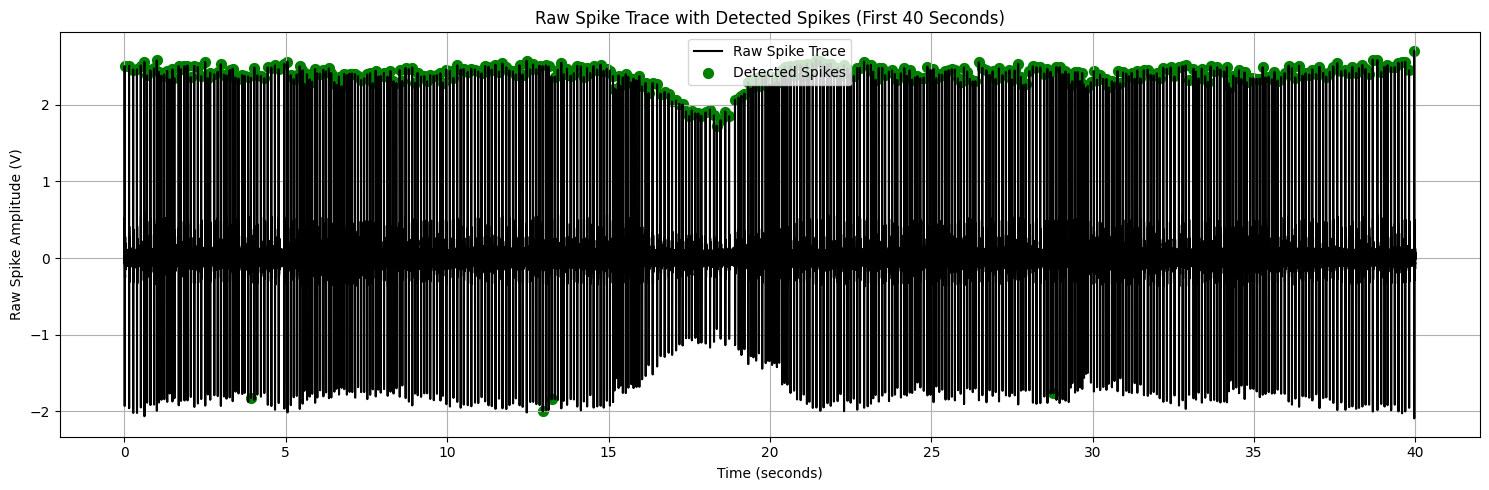

In [10]:
visualize_spike_in_time_window(time_in_seconds, spike_raw, spike_count, sampling_rate, duration=40)

**(Legacy) Interactive raw-channel overview.** A self-contained widget (independent of the cells above): it loads one `.mat` file and plots three raw channels — `spike_raw` (`Data[5]`), the auxiliary `hutchens` channel (`Data[7]`), and `opto_stim` (`Data[6]`) — with a draggable range slider to zoom and a *Save SVG* button that writes the current view next to the `.mat` file. Requires `ipywidgets`.

**（历史遗留）交互式原始通道总览。** 一个自成一体的小部件（不依赖上面的单元）：载入一个 `.mat` 文件并绘制三个原始通道——`spike_raw`（`Data[5]`）、辅助通道 `hutchens`（`Data[7]`）以及 `opto_stim`（`Data[6]`）——配有可拖动的范围滑块用于缩放，以及一个 *Save SVG* 按钮，将当前视图保存到 `.mat` 文件旁。需要 `ipywidgets`。

In [5]:
# =====================================================================
# Raw-data overview: load a .mat file directly and inspect 3 raw channels
# (spike_raw = data[5], hutchens = data[7], opto_stim = data[6])
# Self-contained: does NOT depend on earlier cells. Edit mat_file_path
# below, run this cell, drag the range slider to zoom, click "Save SVG"
# to write the current view next to the .mat file.
# =====================================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Make sure load_and_reshape_data is in scope
%run '/Users/camellyc/Library/Mobile Documents/com~apple~CloudDocs/学习/Lab/Tuthill Lab/Codes/Flight_Arena_Analysis/spiracle_helper_functions.py'

# Editable-text SVG style (Affinity/Illustrator safe)
set_plot_style()

# ---- Inputs (edit me) ----
mat_file_path = '/Users/camellyc/Desktop/untitled folder/SpMN4_ChR_EMG_SpMN4_ChR_5d_F_Fly2_Trial2_5000msx3_thorax_2025_1226_152434.mat'
sampling_rate = 20000  # Hz

# ---- Load full trace ----
data = load_and_reshape_data(mat_file_path, duration=None, sampling_rate=sampling_rate)
spike_raw = data[5]
hutchens  = data[7]
opto_stim = data[6]
n_samples = data.shape[1]
total_duration = n_samples / sampling_rate
time = np.arange(n_samples) / sampling_rate

# ---- Widgets ----
range_slider = widgets.FloatRangeSlider(
    value=[0, total_duration],
    min=0, max=total_duration, step=0.1,
    description='Window (s):',
    continuous_update=False,
    readout_format='.2f',
    layout=widgets.Layout(width='70%'),
)
save_button = widgets.Button(description='Save SVG', button_style='primary')
out = widgets.Output()

_state = {'fig': None, 't0': 0.0, 't1': total_duration}

def _downsample(x, y, max_pts=200_000):
    n = len(x)
    if n <= max_pts:
        return x, y
    step = n // max_pts
    return x[::step], y[::step]

def draw(t0, t1):
    with out:
        out.clear_output(wait=True)
        if _state['fig'] is not None:
            plt.close(_state['fig'])
        i0 = max(0, int(t0 * sampling_rate))
        i1 = min(n_samples, int(t1 * sampling_rate))
        t_win = time[i0:i1]

        fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

        sx, sy = _downsample(t_win, spike_raw[i0:i1])
        axes[0].plot(sx, sy, color='steelblue', linewidth=0.6)
        axes[0].set_ylabel('spike_raw (V)')
        axes[0].set_title(f'Raw channels  |  {t0:.2f} – {t1:.2f} s  ({i1 - i0} pts)')
        axes[0].grid(True, linestyle='--', alpha=0.35)

        hx, hy = _downsample(t_win, hutchens[i0:i1])
        axes[1].plot(hx, hy, color='mediumpurple', linewidth=0.6)
        axes[1].set_ylabel('hutchens (V)')
        axes[1].grid(True, linestyle='--', alpha=0.35)

        ox, oy = _downsample(t_win, opto_stim[i0:i1])
        axes[2].plot(ox, oy, color='darkorange', linewidth=0.9)
        axes[2].set_ylabel('opto_stim (V)')
        axes[2].set_xlabel('time (s)')
        axes[2].grid(True, linestyle='--', alpha=0.35)

        for ax in axes:
            ax.set_xlim(t0, t1)
        plt.tight_layout()
        _state['fig'] = fig
        _state['t0'] = t0
        _state['t1'] = t1
        plt.show()

def on_slider_change(change):
    t0, t1 = change['new']
    draw(t0, t1)

def on_save_clicked(_):
    fig = _state['fig']
    if fig is None:
        print('No figure to save yet.')
        return
    mat_dir = os.path.dirname(mat_file_path)
    mat_stem = os.path.splitext(os.path.basename(mat_file_path))[0]
    out_path = os.path.join(
        mat_dir,
        f"{mat_stem}_overview_{_state['t0']:.2f}-{_state['t1']:.2f}s.svg",
    )
    fig.savefig(out_path, format='svg', bbox_inches='tight')
    print(f'Saved: {out_path}')

range_slider.observe(on_slider_change, names='value')
save_button.on_click(on_save_clicked)

display(widgets.VBox([widgets.HBox([range_slider, save_button]), out]))
draw(0.0, total_duration)


Loaded data shape: (9, 5393000)
